<a href="https://colab.research.google.com/github/Sharddha-Sharddha/CNN-MedMNIST/blob/main/MedMNIST_cnn_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🏥 MEDICAL IMAGE CLASSIFICATION WITH CNN**

*******************************************************

PROJECT TITLE: MedMNIST - Biomedical Image Classifier

OBJECTIVE:
Build an AI model that can automatically identify/classify medical images

**BloodMNIST Dataset Overview:**
- Total Images: ~17,092 blood cell microscope images
- Image Size: 28 x 28 pixels (colored RGB)
- Classes: Different types of blood cells
- Purpose: Detect abnormalities and cell types

In [64]:
!pip install -q tensorflow
!pip install -q keras_tuner

!pip install -q MedMNIST


In [65]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from PIL import Image, ImageOps
import os

import tensorflow as tf
import keras_tuner as kt
from tensorflow.keras import layers, models, callbacks

import warnings
warnings.filterwarnings('ignore')

In [66]:
# Enable Mixed Precision for faster training on modern GPUs (e.g., Tesla T4, V100)
# The policy 'mixed_float16' instructs Keras to use float16 for heavy computations
# while keeping variables in float32 for numeric stability.

from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

Compute dtype: float16
Variable dtype: float32


In [67]:
# import time
# time.sleep(300) #5min

In [68]:
# data loader
from medmnist import BloodMNIST




In [69]:
train_data = BloodMNIST(split = 'train', download = True)
val_data = BloodMNIST(split = 'val', download = True)
test_data = BloodMNIST(split = 'test', download = True)
print("*********BloodMNIST dataset loaded successfully!************")

*********BloodMNIST dataset loaded successfully!************


In [70]:
train_data

Dataset BloodMNIST of size 28 (bloodmnist)
    Number of datapoints: 11959
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
    Number of samples: {'train': 11959, 'val': 1712, 'test': 3421}
    Description: The BloodMNIST is based on a dataset of individual normal cells, captured from individuals without infection, hematologic or oncologic disease and free of any pharmacologic treatment at the moment of blood collection. It contains a total of 17,092 images and is organized into 8 classes. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images with resolution 3×360×363 pixels are center-cropped into 3×200×200, and then resized into 3×28×28.
    License: CC B

In [71]:
print(f"\nTraining Images: {len(train_data)}")
print(f"Validation Images: {len(val_data)}")
print(f"Test Images: {len(test_data)}")

print(f"\nTotal Images: {len(train_data) + len(val_data) + len(test_data)}")



Training Images: 11959
Validation Images: 1712
Test Images: 3421

Total Images: 17092


In [72]:
train_images,train_labels = train_data.imgs, train_data.labels
test_images, test_labels = test_data.imgs, test_data.labels
val_images, val_labels = val_data.imgs, val_data.labels

In [73]:
print(f'training data shape - {train_images.shape}')  # total image 11959 ,pxl are 28*28 and 3 channel information
print(f'testing data shape - {test_images.shape}')
print(f'Validation data shape - {val_images.shape}')

training data shape - (11959, 28, 28, 3)
testing data shape - (3421, 28, 28, 3)
Validation data shape - (1712, 28, 28, 3)


In [74]:
train_images[47]

array([[[223, 183, 192],
        [207, 168, 173],
        [214, 176, 173],
        ...,
        [201, 159, 145],
        [212, 174, 155],
        [217, 179, 158]],

       [[238, 199, 202],
        [206, 168, 167],
        [204, 167, 159],
        ...,
        [224, 182, 168],
        [234, 196, 177],
        [239, 201, 180]],

       [[255, 223, 215],
        [243, 206, 197],
        [217, 181, 167],
        ...,
        [238, 196, 182],
        [246, 208, 189],
        [249, 211, 190]],

       ...,

       [[253, 230, 198],
        [249, 226, 195],
        [255, 229, 202],
        ...,
        [218, 180, 167],
        [222, 184, 173],
        [223, 183, 173]],

       [[252, 228, 202],
        [251, 225, 200],
        [254, 228, 205],
        ...,
        [219, 181, 170],
        [222, 184, 173],
        [223, 185, 174]],

       [[252, 225, 206],
        [251, 224, 205],
        [254, 225, 207],
        ...,
        [218, 182, 170],
        [220, 184, 172],
        [225, 187, 176]]], dtype=uint8)

In [75]:
test_labels[47]

array([1], dtype=uint8)

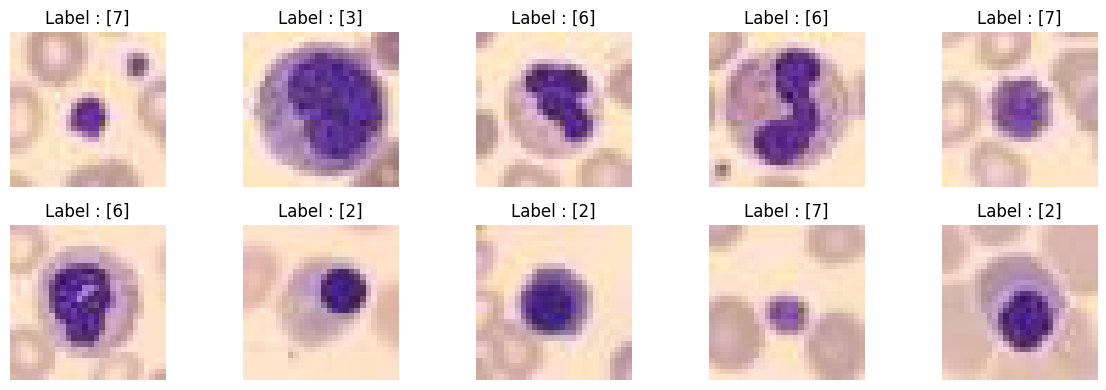

In [76]:
plt.figure(figsize = (12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  img = train_images[i]
  plt.imshow(img)
  plt.title(f'Label : {train_labels[i]}')
  plt.axis('off')
plt.tight_layout()

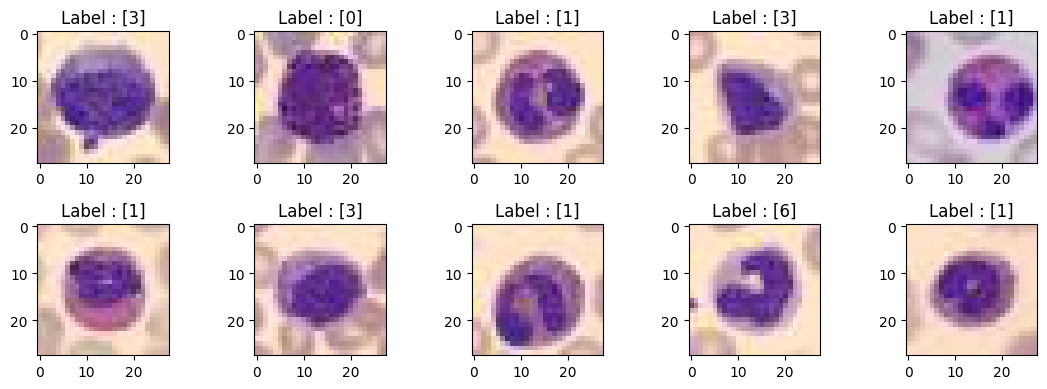

In [77]:
plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  tst_img = test_images[i]
  plt.imshow(tst_img)
  plt.title(f'Label : {test_labels[i]}')
  plt.tight_layout()

In [78]:
#normalisizing the data Pixel values in the RGB images range from [0, 255].
#Neural networks optimize significantly faster when values are scaled to the range [0.0, 1.0].

train_images = train_images.astype('float32')/255.0
test_images = test_images.astype('float32')/255.0
val_images = val_images.astype('float32')/255.0

train_images[1]

array([[[1.        , 0.9098039 , 0.8352941 ],
        [0.99607843, 0.8901961 , 0.80784315],
        [0.9843137 , 0.88235295, 0.78431374],
        ...,
        [0.6862745 , 0.5254902 , 0.5568628 ],
        [0.6313726 , 0.46666667, 0.5137255 ],
        [0.6117647 , 0.4509804 , 0.5137255 ]],

       [[0.99215686, 0.8901961 , 0.7921569 ],
        [1.        , 0.9019608 , 0.8039216 ],
        [1.        , 0.9098039 , 0.8039216 ],
        ...,
        [0.64705884, 0.4862745 , 0.5176471 ],
        [0.61960787, 0.45490196, 0.50980395],
        [0.61960787, 0.45882353, 0.52156866]],

       [[0.9764706 , 0.8784314 , 0.75686276],
        [1.        , 0.9098039 , 0.7882353 ],
        [1.        , 0.91764706, 0.79607844],
        ...,
        [0.6627451 , 0.49803922, 0.54509807],
        [0.654902  , 0.49411765, 0.5568628 ],
        [0.68235296, 0.52156866, 0.5921569 ]],

       ...,

       [[0.99607843, 0.9137255 , 0.7372549 ],
        [0.99607843, 0.9137255 , 0.74509805],
        [0.99607843, 0

In [79]:
train_images.shape

(11959, 28, 28, 3)

In [80]:
train_labels.shape

(11959, 1)

In [81]:
#.squeeze() flattens [[0], [3], [1], [5]] into [0, 3, 1, 5].
#The shape changes from (4, 1) to a simple (4,).
#It gets rid of that useless extra dimension of size 1.
train_labels = train_labels.squeeze()
test_labels = test_labels.squeeze()
val_labels = val_labels.squeeze()


train_labels.shape

(11959,)

In [82]:
# 4. Extract class metadata from train_data info
labels_dict = train_data.info['label']
n_classes = len(labels_dict)
class_names = [labels_dict[str(i)] for i in range(n_classes)]

print("Label shapes:", train_labels.shape, val_labels.shape, test_labels.shape)
print(f"Number of classes: {n_classes}")
class_names

Label shapes: (11959,) (1712,) (3421,)
Number of classes: 8


['basophil',
 'eosinophil',
 'erythroblast',
 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)',
 'lymphocyte',
 'monocyte',
 'neutrophil',
 'platelet']

In [83]:
# Data Augmentation (Creating Synthetic Variations)
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomFlip('Horizontal'),
    layers.RandomTranslation(0.05,0.05),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1)
    ], name = 'data_augmentation')


# **# Constructing the CNN model architecture**

In [84]:
def create_model():

  model = models.Sequential([
    #first Convulation Block
    layers.Input(shape= (28,28,3)),
    data_augmentation,
    # Conv2D: Find patterns in images
    # 32 filters = detect 32 different patterns
    # (3,3) = look at 3x3 pixel windows
    # 'leaky_relu' = activation function (makes it non-linear)
    layers.Conv2D(32,(3,3), padding= 'same', activation= 'leaky_relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), padding= 'same', activation= 'leaky_relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.30),

    #second Convulation Block
    layers.Conv2D(64,(3,3), padding= 'same', activation= 'leaky_relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3), padding= 'same', activation= 'leaky_relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.50),

    # flatten the layers
    layers.GlobalAveragePooling2D(),

    #ann Architecture
    layers.Dense(units = 128, activation= 'leaky_relu', kernel_regularizer= tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.50),

    layers.Dense(units = 8, activation='softmax')

  ], name = 'bloodMNIST')
  return model

In [85]:
model = create_model()

In [86]:
model.summary()

Model: "bloodMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149,384 (583.53 KB)

 Trainable params: 148,552 (580.28 KB)

 Non-trainable params: 832 (3.25 KB)

In [87]:
# learning rate schedule - lr decay
# Gradually reduce the learning rate to fine-tune weights and avoid overshooting the minimum
lr_decy = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate = 0.01,
    decay_steps = 1000,
    decay_rate = 0.90
)

In [88]:
optimizer= tf.keras.optimizers.Adam(learning_rate= lr_decy)

In [89]:
# Compiling the model
# Using sparse_categorical_crossentropy because labels are integers
model.compile(
    optimizer = optimizer,
    loss= 'sparse_categorical_crossentropy',
    metrics= ['accuracy']
)

In [90]:
# callback mechanism
early_stoping = callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    mode = 'min'
)

checkpoint = callbacks.ModelCheckpoint(
    'best_blood_cell_model.keras',  # Save file name
    monitor = 'val_accuracy',
    mode = 'max',
    save_best_only = True,
    verbose = 1
)

# #reduce learning rate when val_loss stops improving
# reduce_lr = callbacks.ReduceLROnPlateau(
#     monitor = 'val_loss',
#     patience = 7,
#     mode = min,
#     factor=0.5,
#     min_lr=1e-6,     # Absolute lower bound limit for the learning rate# Multiply current learning rate by 0.5
# )


callback = [early_stoping, checkpoint]

In [91]:
# model_training
history = model.fit(
    train_images,
    train_labels,
    batch_size = 128,
    epochs=30,
    validation_data = (val_images, val_labels),
    callbacks = callback
)

Epoch 1/30
91/94 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4472 - loss: 1.9527
Epoch 1: val_accuracy improved from None to 0.18984, saving model to best_blood_cell_model.keras

Epoch 1: finished saving model to best_blood_cell_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.6027 - loss: 1.3238 - val_accuracy: 0.1898 - val_loss: 7.3882
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7490 - loss: 0.7943
Epoch 2: val_accuracy did not improve from 0.18984
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7575 - loss: 0.7435 - val_accuracy: 0.1770 - val_loss: 3.7180
Epoch 3/30
92/94 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7837 - loss: 0.6615
Epoch 3: val_accuracy improved from 0.18984 to 0.26227, saving model to best_blood_cell_model.keras

Epoch 3: finished saving model to best_blood_cell_model.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7882 - loss: 0.6420 - val_accuracy: 0.2623 - val_loss: 6.3095
Epoch 4/30
91/94 ━━━━━

In [92]:
# # Clear all cache
# !rm -rf ~/.keras
# !rm -rf ~/.cache
# !rm -rf /tmp/*

# print("✅ Cache cleared!")

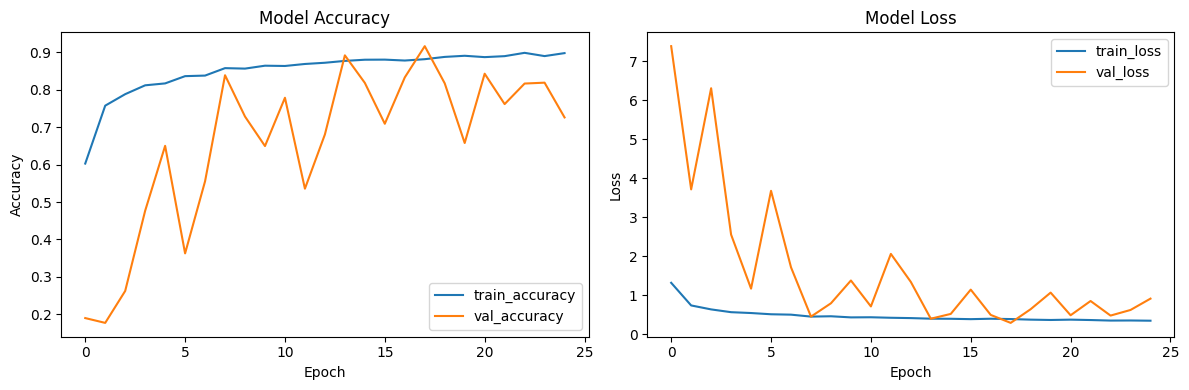

In [93]:
# Creating the figure and two subplots (axes)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot Accuracy
ax[0].plot(history.history['accuracy'], label='train_accuracy')
ax[0].plot(history.history['val_accuracy'], label='val_accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Plot Loss
ax[1].plot(history.history['loss'], label='train_loss')
ax[1].plot(history.history['val_loss'], label='val_loss')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

In [94]:
#model.load('best_blood_cell_model.keras')

In [95]:
# best validation loss and accuracy
best_val_accuracy = np.argmax(history.history['val_accuracy'])
val_loss = history.history['val_loss'][best_val_accuracy]
val_acc = history.history['val_accuracy'][best_val_accuracy]
print(f'validation loss : {val_loss:.2f}\nvalidation accuracy : {val_acc*100:.2f}')

validation loss : 0.30
validation accuracy : 91.65


In [96]:
test_loss, test_accuracy = model.evaluate(test_images,test_labels)
print(f'test loss: {test_loss:.2f}\ntest accuracy: {test_accuracy*100:.2f}')

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7270 - loss: 0.9558
test loss: 0.96
test accuracy: 72.70


# **Overfitting problem**
validation accuracy -> 91.65 %
test accuracy -> 72.70

difference -> 18.95% -> overfitting

To remove the overfitting problem we can tweek few parameter's like reducing the learning rate, change the data augmentation parameter values, increase the dropout etc

In [97]:
# learning rate schedule - lr decay
# Gradually reduce the learning rate to fine-tune weights and avoid overshooting the minimum
lr_decy = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate = 0.001,
    decay_steps = 1000,
    decay_rate = 0.90
)

In [98]:
optimizer= tf.keras.optimizers.Adam(learning_rate= lr_decy)

In [99]:
# Compiling the model
# Using sparse_categorical_crossentropy because labels are integers
model.compile(
    optimizer = optimizer,
    loss= 'sparse_categorical_crossentropy',
    metrics= ['accuracy']
)

In [100]:
# callback mechanism
early_stoping = callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 7,
    mode = 'min'
)

checkpoint = callbacks.ModelCheckpoint(
    'best_blood_cell_model_1.keras',  # Save file name
    monitor = 'val_accuracy',
    mode = 'max',
    save_best_only = True,
    verbose = 1
)

# #reduce learning rate when val_loss stops improving
# reduce_lr = callbacks.ReduceLROnPlateau(
#     monitor = 'val_loss',
#     patience = 7,
#     mode = min,
#     factor=0.5,
#     min_lr=1e-6,     # Absolute lower bound limit for the learning rate# Multiply current learning rate by 0.5
# )


callback = [early_stoping, checkpoint]

In [101]:
# model_training
history = model.fit(
    train_images,
    train_labels,
    batch_size = 128,
    epochs=30,
    validation_data = (val_images, val_labels),
    callbacks = callback
)

Epoch 1/30
92/94 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9059 - loss: 0.3163
Epoch 1: val_accuracy improved from None to 0.91121, saving model to best_blood_cell_model_1.keras

Epoch 1: finished saving model to best_blood_cell_model_1.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9103 - loss: 0.3014 - val_accuracy: 0.9112 - val_loss: 0.3134
Epoch 2/30
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9134 - loss: 0.2930
Epoch 2: val_accuracy improved from 0.91121 to 0.91881, saving model to best_blood_cell_model_1.keras

Epoch 2: finished saving model to best_blood_cell_model_1.keras
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9171 - loss: 0.2785 - val_accuracy: 0.9188 - val_loss: 0.2704
Epoch 3/30
92/94 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9179 - loss: 0.2694
Epoch 3: val_accuracy did not improve from 0.91881
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9168 - loss: 0.2684 - val_accuracy: 0.9036 - val_loss: 0.2858
Epoch 4/30
91/9

In [102]:
# # Clear all cache
# !rm -rf ~/.keras
# !rm -rf ~/.cache
# !rm -rf /tmp/*

# print("✅ Cache cleared!")

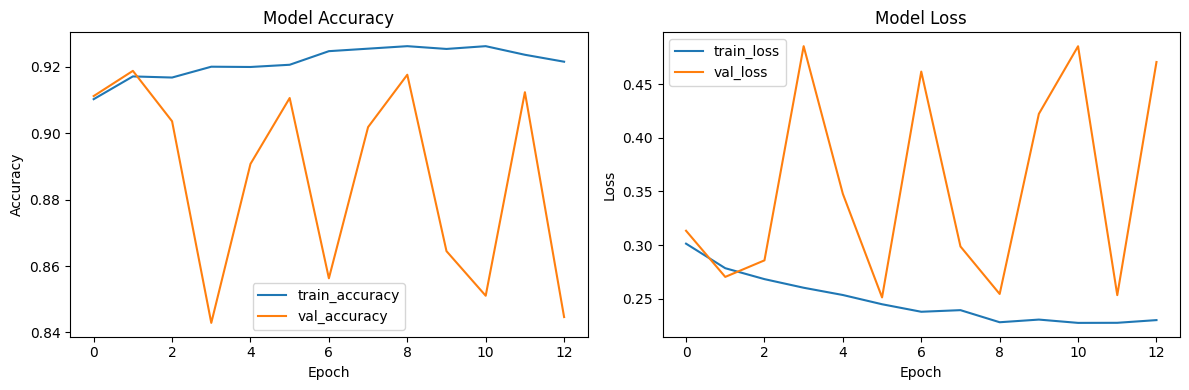

In [103]:
# Creating the figure and two subplots (axes)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot Accuracy
ax[0].plot(history.history['accuracy'], label='train_accuracy')
ax[0].plot(history.history['val_accuracy'], label='val_accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Plot Loss
ax[1].plot(history.history['loss'], label='train_loss')
ax[1].plot(history.history['val_loss'], label='val_loss')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

In [104]:
#model.load('best_blood_cell_model.keras')

In [105]:
# best validation loss and accuracy
best_val_accuracy = np.argmax(history.history['val_accuracy'])
val_loss = history.history['val_loss'][best_val_accuracy]
val_acc = history.history['val_accuracy'][best_val_accuracy]
print(f'validation loss : {val_loss:.2f}\nvalidation accuracy : {val_acc*100:.2f}')

validation loss : 0.27
validation accuracy : 91.88


In [106]:
test_loss, test_accuracy = model.evaluate(test_images,test_labels)
print(f'test loss: {test_loss:.2f}\ntest accuracy: {test_accuracy*100:.2f}')

107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8384 - loss: 0.5118
test loss: 0.51
test accuracy: 83.84


**Model Improved by 57.52 %**

validation accuracy -> 91.88 %
test accuracy -> 83.84 %

difference -> 8.04%



In [107]:
prediction = model.predict(test_images)


# Get predicted class (class with highest probability)
predicted_classes = np.argmax(prediction, axis=1)

print(f"✅ Predictions made for {len(test_images)} test images")
print(f"\nExample predictions:")
print(f"  First 10 predictions: {predicted_classes[:10]}")
print(f"  First 10 actual labels: {test_labels[:10]}")

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
✅ Predictions made for 3421 test images

Example predictions:
  First 10 predictions: [3 0 1 3 1 1 3 1 6 0]
  First 10 actual labels: [3 0 1 3 1 1 3 1 6 1]



📊 STEP 5: CONFUSION MATRIX
----------------------------------------------------------------------


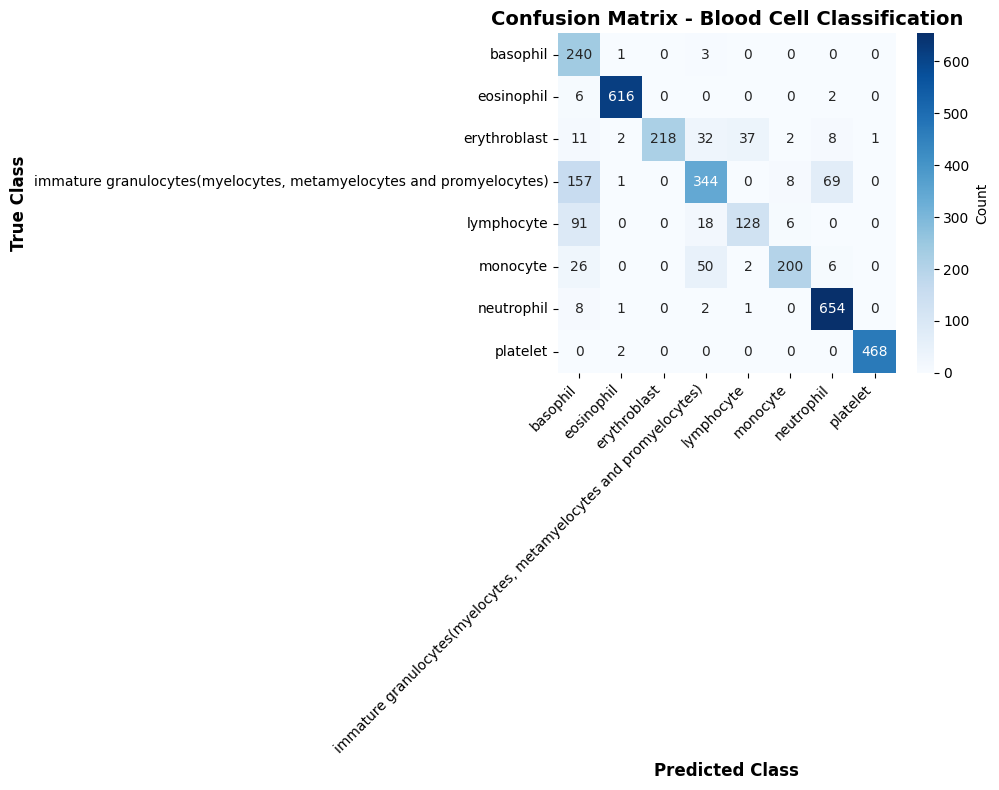

✅ Confusion matrix plotted!


In [108]:
# STEP 5: CONFUSION MATRIX
# Shows which classes are confused with each other

print("\n📊 STEP 5: CONFUSION MATRIX")
print("-"*70)

# Calculate confusion matrix
cm = confusion_matrix(test_labels, predicted_classes)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'},
            ax=ax)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
ax.set_ylabel('True Class', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Blood Cell Classification', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("✅ Confusion matrix plotted!")

# **DEPLOYEMENT**

In [112]:
load_model = tf.keras.models.load_model('best_blood_cell_model_1.keras')

load_model.summary()

Model: "bloodMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 446,493 (1.70 MB)

 Trainable params: 148,552 (580.28 KB)

 Non-trainable params: 832 (3.25 KB)

 Optimizer params: 297,109 (1.13 MB)